=== Probabilities ===
P(pass) = 0.5730
P(pass | study) = 0.6960
P(pass | not study) = 0.3800

=== Independence Test ===
Events are NOT independent.


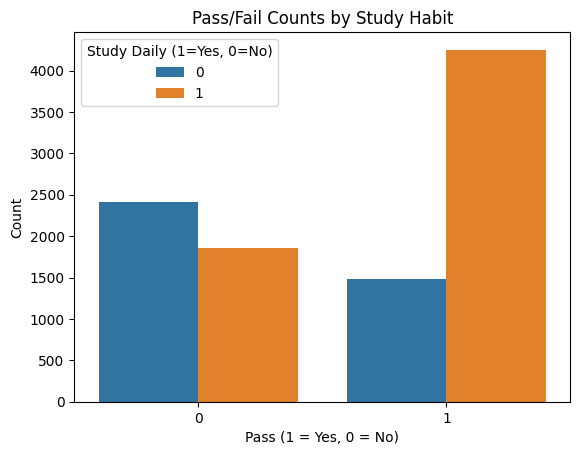

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

np.random.seed(42)

n= 10000

study = np.random.rand(n) < 0.6

pass_exam = np.zeros(n, dtype=int)

study_idx = study == 1
not_study_idx = study == 0


pass_exam[study_idx] = (np.random.rand(np.sum(study_idx)) < 0.7)
pass_exam[not_study_idx] = (np.random.rand(np.sum(not_study_idx)) < 0.4)

df = pd.DataFrame({
    'study': study.astype(int),
    'pass': pass_exam
})

P_pass = df['pass'].mean()
P_pass_given_study = df[df.study == 1]['pass'].mean()
P_pass_given_not_study = df[df.study == 0]['pass'].mean()

print("=== Probabilities ===")
print(f"P(pass) = {P_pass:.4f}")
print(f"P(pass | study) = {P_pass_given_study:.4f}")
print(f"P(pass | not study) = {P_pass_given_not_study:.4f}")

print("\n=== Independence Test ===")
if np.isclose(P_pass_given_study, P_pass_given_not_study):
    print("Events appear independent.")
else:
    print("Events are NOT independent.")

plt.figure()
sns.countplot(data=df, x='pass', hue='study')

plt.title("Pass/Fail Counts by Study Habit")
plt.xlabel("Pass (1 = Yes, 0 = No)")
plt.ylabel("Count")
plt.legend(title="Study Daily (1=Yes, 0=No)")

plt.show()

